# PHYS303 / CS686 Final Submission — Spectrum-FM

**Unimodal foundation model for DESI spectra + redshift.**

This notebook is the instructor-facing deliverable: project summary, official checkpoints, training/data documentation, and runnable inference on your spectra.

**Requirements addressed** (see `PHYS303_Final-Project_2026.pdf`):
- Foundation model with masked token reconstruction (not a pure CNN regressor)
- Approach A: encoder sees redshift token; joint spectrum + z modeling
- Approach B: encoder never sees z (negative result — metrics only, no checkpoint)
- Evaluation on redshift prediction and spectrum reconstruction


## 1. Setup


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.inference.release import (
    RELEASE_ROOT,
    DEFAULT_TRANSFORMER_ID,
    load_manifest,
    list_release_models,
    load_release_models,
    numpy_spectrum_batch,
    predict_teacher_forced,
    predict_autoregressive,
    decode_z_from_token,
    decode_spectrum_tokens_to_flux,
    get_device,
)
from src.tokenizers.spectrum import N_TOKENS as N_SPEC_TOKENS
from src.utils.data import DESISpectrumDataset

plt.rcParams['figure.dpi'] = 110


## 2. Official release models (W&B → repo)


In [2]:
manifest = load_manifest()
print(f'W&B: {manifest["wandb_entity"]}/{manifest["wandb_project"]}')
print(f'Release root: {RELEASE_ROOT}\n')

rows = list_release_models()
for r in rows:
    status = 'OK' if r['exists'] else 'MISSING (run: git lfs pull)'
    print(f"  [{status}] {r['model_id']}")
    print(f"         {r['display_name']}")
    print(f"         {r['checkpoint']}")
    print(f"         wandb: {r['wandb_artifact']}\n")

MODEL_ID = manifest['default_transformer']
DATA_DIR = REPO / 'data' / 'desi_raw'
N_SAMPLES = 4
SEED = 42


W&B: jjayaseelan-university-of-san-francisco/redshifty
Release root: /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release

  [OK] spectrum_tokenizer_v1
         Spectrum-FM Spectrum Tokenizer v1
         /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release/spectrum_tokenizer_v1/best.pt
         wandb: jjayaseelan-university-of-san-francisco/redshifty/spectrum_tokenizer_v1:best

  [OK] transformer_approach_a_fm_v1_10k_ddp4_rw10_v8
         Spectrum-FM Transformer — Approach A (encoder sees z)
         /Users/jonathansamuel/projects/cs-686-dl/FoundationModel/checkpoints/release/transformer_approach_a_fm_v1_10k_ddp4_rw10_v8/best.pt
         wandb: jjayaseelan-university-of-san-francisco/redshifty/approach_a_fm_v1_10k_a_ddp4_rw10_v8:best



## 3. Architecture (summary)

```text
DESI spectrum (flux, ivar)
    → SpectrumTokenizer v1 (ConvNeXt + LFQ, frozen)
    → 272 spectrum tokens + 1 redshift token
    → Encoder–decoder Transformer (RoPE, 768-d, 6+6 layers)
    → Predict redshift bin + spectrum tokens
```

- **Vocab size**: 1288 (special tokens + 1024 spectrum + 256 redshift bins)
- **Approach A**: encoder input `[SOS, z_tok, spec_toks…]` — redshift visible bidirectionally
- **Approach B** (not shipped): encoder sees spectrum only; decoder must infer z (failed in our runs)


## 4. Training

| Stage | Script | Output |
|-------|--------|--------|
| Tokenizer pretrain | `nersc/pretrain_tokenizer.py` | `spectrum_tokenizer_v1` |
| Transformer A | `nersc/train_transformer.py --approach a` | `approach_a_fm_v1_10k_a_ddp4_redmask50_v9` |

- **Data**: DESI DR1 manifest (~10k healpix), 5% healpix-file holdout for validation
- **Compute**: NERSC Perlmutter A100; logs to W&B project `redshifty`
- **Release model** (`fm_v1_10k_a_ddp4_rw10_v8`, W&B run `8fglr5zl`): 10k-healpix manifest, mask ratio 0.5, **redshift loss weight 1**, batch 32, best step 22000
- **Metrics source**: `checkpoints/release/MANIFEST.json` (synced from W&B; run `python scripts/sync_wandb_metrics.py` to refresh)


## 5. Load models


In [3]:
device = get_device()
try:
    model, spec_tok, z_tok, cfg = load_release_models(MODEL_ID, device=device)
    APPROACH = cfg['approach']
    print(f"Loaded {cfg['display_name']}")
    print(f"  approach={APPROACH}  d_model={cfg.get('d_model')}  mask_ratio={cfg.get('encoder_mask_ratio')}")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  transformer params: {n_params/1e6:.1f}M")
except FileNotFoundError as e:
    print(e)
    model = spec_tok = z_tok = None


Loaded Spectrum-FM Transformer — Approach A (encoder sees z)
  approach=a  d_model=768  mask_ratio=0.5
  transformer params: 100.1M


## 6. Approach B — logged results only (no checkpoint)

No Approach B weights are included. Metrics below are from W&B (`phase10_mask50_b`, run `3na766th`). The release Approach A checkpoint is a **different** run (`fm_v1_10k_a_ddp4_rw10_v8`) — do not mix with `phase10_mask50_a_big` numbers from the research log.


In [4]:
def _pct(x):
    return f"{100*float(x):.1f}%" if x not in (None, '') else '—'

a = manifest.get('approach_a_results', {})
b = manifest.get('approach_b_results', {})
ref = manifest.get('reference_runs', {}).get('phase10_mask50_a_big', {})
print(f"Source: {manifest.get('metrics_source', 'MANIFEST.json')}\n")
hdr = f"{'Model':<18} {'run':<28} {'z_TF':>7} {'z_AR':>7} {'spec_TF':>8} {'spec_AR':>8} {'rw':>4}"
print(hdr)
print('-' * len(hdr))
for label, row in [
    ('A release', a),
    ('B (no ckpt)', b),
    ('A phase10 ref', ref),
]:
    print(f"{label:<18} {row.get('training_run',''):<28} "
          f"{_pct(row.get('val_redshift_acc_teacher_forced')):>7} "
          f"{_pct(row.get('val_redshift_acc_autoregressive')):>7} "
          f"{_pct(row.get('val_spectrum_acc_teacher_forced')):>8} "
          f"{_pct(row.get('val_spectrum_acc_autoregressive')):>8} "
          f"{row.get('redshift_loss_weight',''):>4}")
print()
print(b.get('conclusion', ''))
if a.get('wandb_run_url'):
    print(f"Release run: {a['wandb_run_url']}")


Source: W&B API (verified 2026-05-20)

Model              run                             z_TF    z_AR  spec_TF  spec_AR   rw
--------------------------------------------------------------------------------------
A release          fm_v1_10k_a_ddp4_rw10_v8      100.0%  100.0%    72.8%    64.7%  1.0
B (no ckpt)        phase10_mask50_b                1.8%    3.6%    28.2%     5.3% 50.0
A phase10 ref                                     73.8%   55.0%    24.0%     1.2% 50.0

Encoder does not learn redshift from spectrum alone; contrast with Approach A release model.


## 7. Instructor test — your spectra (NumPy)

Provide `flux` and `ivar` as 1D arrays (one spectrum) or 2D `(batch, length)`.
Optional `z_true` for error metrics.


In [5]:
# --- EDIT: point at your data ---
# Example synthetic smoke (replace with real arrays):
L = 8000
flux = np.random.randn(L).astype(np.float32) * 0.1
ivar = np.ones(L, dtype=np.float32) * 100.0
z_true = np.array([0.15], dtype=np.float32)

if model is None:
    print('Models not loaded — fix checkpoints first (git lfs pull).')
else:
    batch = numpy_spectrum_batch(flux, ivar, z=z_true)
    _, _, tgt, pred, denorm = predict_teacher_forced(
        batch, model, spec_tok, z_tok, APPROACH, device,
    )
    z_tok_id = int(pred[0, 0].item())
    z_pred = decode_z_from_token(z_tok_id, z_tok)
    print(f'Predicted z (teacher-forced): {z_pred:+.4f}')
    if z_true is not None:
        print(f'True z: {float(z_true.ravel()[0]):+.4f}  |error|={abs(z_pred - float(z_true.ravel()[0])):.4f}')


Predicted z (teacher-forced): +0.1485
True z: +0.1500  |error|=0.0015


## 8. Optional — DESI FITS from `data/desi_raw/`


In [6]:
if model is None:
    print('Skip FITS eval — models not loaded.')
elif not DATA_DIR.is_dir() or not list(DATA_DIR.glob('coadd-*.fits')):
    print(f'No FITS in {DATA_DIR}. See data/README.md to download smoke data.')
else:
    coadd_files = sorted(DATA_DIR.glob('coadd-*.fits'))
    spectra = []
    for f in coadd_files[:2]:
        rr = f.parent / f.name.replace('coadd-', 'redrock-')
        if not rr.exists():
            continue
        ds = DESISpectrumDataset(f, rr, require_good_zwarn=True, require_nonzero_flux=True)
        for i in range(min(len(ds), N_SAMPLES)):
            spectra.append(ds[i])
    if not spectra:
        print('No good spectra loaded.')
    else:
        rng = torch.Generator().manual_seed(SEED)
        idx = torch.randperm(len(spectra), generator=rng)[:N_SAMPLES].tolist()
        sample = [spectra[i] for i in idx]
        Lmax = max(s['flux'].shape[0] for s in sample)
        def pad(t, fill=0.0):
            if t.shape[0] == Lmax: return t
            out = torch.full((Lmax,), fill, dtype=t.dtype)
            out[:t.shape[0]] = t
            return out
        batch = {
            'flux': torch.stack([pad(s['flux']) for s in sample]),
            'ivar': torch.stack([pad(s['ivar'], 0.0) for s in sample]),
            'z': torch.stack([s['z'] for s in sample]).float(),
        }
        _, _, tgt, pred, denorm = predict_teacher_forced(batch, model, spec_tok, z_tok, APPROACH, device)
        z_pred = [decode_z_from_token(int(pred[i,0]), z_tok) for i in range(len(sample))]
        for i, s in enumerate(sample):
            print(f'  z_true={float(s["z"]):+.4f}  z_pred={z_pred[i]:+.4f}')
        generated, _ = predict_autoregressive(batch, model, spec_tok, z_tok, APPROACH, device)
        z_ar = [decode_z_from_token(int(generated[i,1]), z_tok) for i in range(len(sample))]
        z_true_t = batch['z']
        tf_mae = np.mean([abs(z_pred[i]-float(z_true_t[i])) for i in range(len(sample))])
        ar_mae = np.mean([abs(z_ar[i]-float(z_true_t[i])) for i in range(len(sample))])
        print(f'Batch MAE — teacher-forced: {tf_mae:.4f}  autoregressive: {ar_mae:.4f}')


  Filtered out 18 bad spectra:
    18 bad fiber status
Loaded 25 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 1 bad spectra:
    1 bad ZWARN
Loaded 4 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  z_true=+0.3083  z_pred=+0.3098
  z_true=-0.0001  z_pred=-0.0001
  z_true=+0.2004  z_pred=+0.2002
  z_true=+0.2766  z_pred=+0.2775
Batch MAE — teacher-forced: 0.0006  autoregressive: 0.0006


## 9. Quick visualization (if FITS data loaded above)


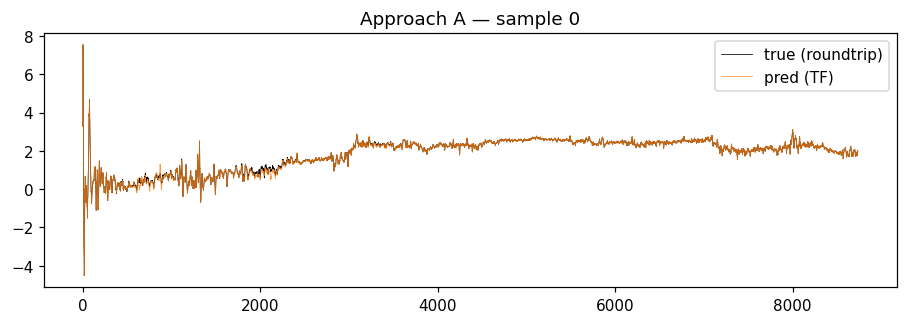

In [7]:
try:
    spec_toks = pred[:, 1:1+N_SPEC_TOKENS]
    pred_flux = decode_spectrum_tokens_to_flux(spec_toks, spec_tok, denorm)[0].cpu().numpy()
    true_toks = tgt[:, 1:1+N_SPEC_TOKENS]
    true_flux = decode_spectrum_tokens_to_flux(true_toks, spec_tok, denorm)[0].cpu().numpy()
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(true_flux, 'k', lw=0.5, label='true (roundtrip)')
    ax.plot(pred_flux, color='C1', lw=0.5, alpha=0.8, label='pred (TF)')
    ax.legend()
    ax.set_title(f'Approach {APPROACH.upper()} — sample 0')
    plt.show()
except NameError:
    print('Run section 8 with data first.')


## 10. CLI evaluation

```bash
python scripts/evaluate.py \
  --checkpoint checkpoints/release/approach_a_fm_v1_10k_a_ddp4_redmask50_v9/best.pt \
  --approach a --data_dir data/desi_raw
```

See also `notebooks/07_visualize_predictions.ipynb` for detailed plots.
